In [7]:
import pandas as pd
import seaborn as sns

WEIGHT_RATIO = 0.1875
THREADS_TO_KEEP = None

In [10]:
data = pd.read_csv("eevdf_thread_inbalance.csv")
data = data[data["weight_ratio"] == WEIGHT_RATIO]

if THREADS_TO_KEEP is not None:
    data = data[
        (data["target_threads"] <= THREADS_TO_KEEP)
        & (data["contention_threads"] <= THREADS_TO_KEEP)
    ]

data["runtime_ratio"] = data["target_runtime"] / (
    data["target_runtime"] + data["contention_runtime"]
)
data["error"] = (WEIGHT_RATIO - data["runtime_ratio"]).abs() * 100
data

,weight_ratio,target_threads,contention_threads,target_runtime,contention_runtime,runtime_ratio,error
143,0.1875,2,7,50093.310,189524.905,0.209055,2.155468
144,0.1875,2,8,45822.664,193804.913,0.191225,0.372450
145,0.1875,2,9,44248.096,195359.970,0.184669,0.283136
146,0.1875,2,10,26044.756,213569.307,0.108695,7.880539
147,0.1875,2,11,47709.152,191907.867,0.199106,1.160586
...,...,...,...,...,...,...,...
270,0.1875,12,14,44921.563,194692.778,0.187474,0.002557
271,0.1875,12,15,45241.497,194376.432,0.188807,0.130681
272,0.1875,12,16,43828.489,195785.027,0.182913,0.458674
273,0.1875,12,17,44683.025,194866.722,0.186529,0.097079


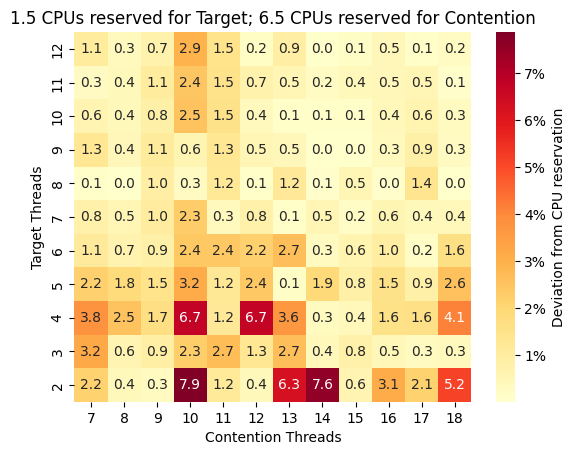

In [11]:
map = data.pivot_table(
    index="target_threads",
    columns="contention_threads",
    values="error",
)
ax = sns.heatmap(
    map,
    annot=True,
    fmt=".1f",
    cbar_kws={"label": "Deviation from CPU reservation", "format": "%.0f%%"},
    cmap="YlOrRd",
    xticklabels=map.columns,
    yticklabels=map.index,
)
ax.set_title("1.5 CPUs reserved for Target; 6.5 CPUs reserved for Contention")
ax.set_xlabel("Contention Threads")
ax.set_ylabel("Target Threads")
ax.invert_yaxis()